# 16.C21A/18.C21A Problem Set #4 — Solutions
Due Wednesday 29 April 2026

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'font.size': 11})

## Problem 1: Finite Element for Two Connecting Materials (10+6+8+14+6+4+12)

Consider a steady-state diffusion problem for two connecting materials.
The governing equations are
$$
(k^{a}T^{a}_{x})_x = -f^{a}, \qquad x\in(0,\tfrac{1}{2}),
$$
$$
(k^{b}T^{b}_{x})_x = -f^{b}, \qquad x\in(\tfrac{1}{2}, 1),
$$
with homogeneous Dirichlet boundary conditions
$$
T^{a}(x=0) = 0, \qquad T^{b}(x=1) = 0,
$$
and interface conditions to impose continuity of the solution (temperature) and heat flux
$$
T^{a}(x=\tfrac{1}{2}) = T^{b}(x=\tfrac{1}{2}), \qquad
k^{a}(x=\tfrac{1}{2})\,T_x^{a}(x=\tfrac{1}{2}) =
k^{b}(x=\tfrac{1}{2})\,T_x^{b}(x=\tfrac{1}{2}).
$$

**1(a)** Using the Galerkin method and ignoring boundary and interface conditions for this part only, what are the resulting weighted residuals involving at most first derivatives? How many equations of weighted residual are there?

### Solution Problem 1(a)

Multiply each governing equation by a test function $\phi_j$ and integrate over the respective subdomain.

**Region $a$** ($0 < x < \tfrac{1}{2}$):
$$
\int_0^{1/2} \phi_j\,(k^a T^a_x)_x\,dx = -\int_0^{1/2} \phi_j\,f^a\,dx.
$$
Integrating by parts to reduce to first derivatives:
$$
\left[\phi_j\,k^a T^a_x\right]_0^{1/2}
- \int_0^{1/2} \phi_{j,x}\,k^a T^a_x\,dx
= -\int_0^{1/2} \phi_j\,f^a\,dx.
$$

**Region $b$** ($\tfrac{1}{2} < x < 1$):
$$
\left[\phi_j\,k^b T^b_x\right]_{1/2}^{1}
- \int_{1/2}^{1} \phi_{j,x}\,k^b T^b_x\,dx
= -\int_{1/2}^{1} \phi_j\,f^b\,dx.
$$

**Combined weighted residual.** Adding the two equations for a global basis function $\phi_j$ defined on $[0,1]$:
$$
R_j = \underbrace{\left[\phi_j\,k^a T^a_x\right]_0^{1/2}
+ \left[\phi_j\,k^b T^b_x\right]_{1/2}^{1}}_{\text{boundary/interface terms}}
- \int_0^{1/2} \phi_{j,x}\,k^a T^a_x\,dx
- \int_{1/2}^{1} \phi_{j,x}\,k^b T^b_x\,dx
+ \int_0^{1/2} \phi_j\,f^a\,dx
+ \int_{1/2}^{1} \phi_j\,f^b\,dx
= 0.
$$

The integrands now involve at most **first derivatives** of $T$ and $\phi_j$.

If there are $N$ elements and $N+1$ nodes, then there are **$N+1$ weighted residual equations** (one per node, before applying boundary conditions).

**1(b)** Assuming the basis functions $\phi_i$ are linear nodal basis. Suppose $N=6$ elements are used, draw all the basis functions and label them. Remember to take into account the boundary conditions. Also clearly label the element and node indices (i.e., things like $\mathrm{elem}_4$ and $x_3$).

### Solution Problem 1(b)

With $N=6$ equal elements on $[0,1]$, the element size is $h=1/6$. The nodes are
$$
x_0=0,\quad x_1=\tfrac{1}{6},\quad x_2=\tfrac{1}{3},\quad x_3=\tfrac{1}{2},\quad x_4=\tfrac{2}{3},\quad x_5=\tfrac{5}{6},\quad x_6=1.
$$
The elements are
$$
\mathrm{elem}_1=[x_0,x_1],\quad \mathrm{elem}_2=[x_1,x_2],\quad \mathrm{elem}_3=[x_2,x_3],\quad \mathrm{elem}_4=[x_3,x_4],\quad \mathrm{elem}_5=[x_4,x_5],\quad \mathrm{elem}_6=[x_5,x_6].
$$
Elements 1–3 lie in material $a$ ($x\in[0,1/2]$) and elements 4–6 lie in material $b$ ($x\in[1/2,1]$).

The linear nodal basis functions are the standard hat functions: $\phi_i(x_j)=\delta_{ij}$. Each $\phi_i$ is nonzero only on the two elements sharing node $x_i$ (or one element for the boundary nodes).

After applying the homogeneous Dirichlet BCs $T(x_0)=0$ and $T(x_6)=0$, we eliminate $\phi_0$ and $\phi_6$. The **5 active basis functions** are $\phi_1,\phi_2,\phi_3,\phi_4,\phi_5$.

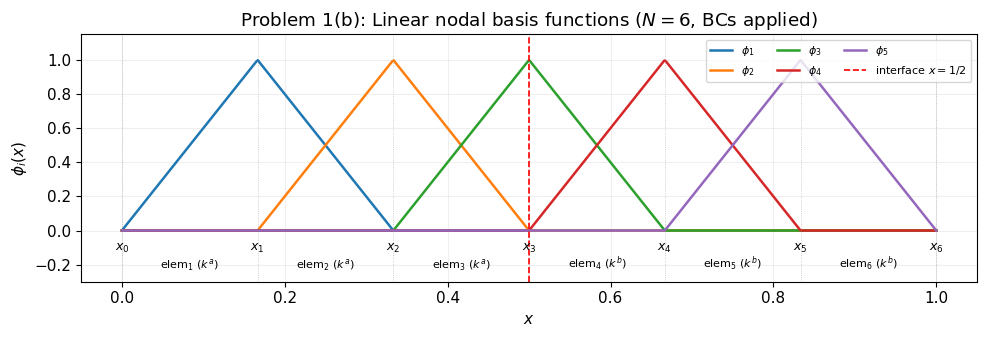

In [7]:
# ── Problem 1(b): sketch of basis functions for N=6 ──

N = 6
h = 1.0 / N
nodes = np.linspace(0, 1, N + 1)

fig, ax = plt.subplots(figsize=(10, 3.5))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# Draw the 5 active hat functions (phi_1 through phi_5)
x_fine = np.linspace(0, 1, 600)
for j in range(1, N):
    phi = np.zeros_like(x_fine)
    mask_l = (x_fine >= nodes[j-1]) & (x_fine <= nodes[j])
    mask_r = (x_fine >= nodes[j]) & (x_fine <= nodes[j+1])
    phi[mask_l] = (x_fine[mask_l] - nodes[j-1]) / h
    phi[mask_r] = (nodes[j+1] - x_fine[mask_r]) / h
    ax.plot(x_fine, phi, lw=1.8, color=colors[(j-1) % len(colors)],
            label=f'$\\phi_{j}$')

# Mark nodes and elements
for i, xi in enumerate(nodes):
    ax.axvline(xi, color='grey', ls=':', lw=0.6, alpha=0.5)
    ax.text(xi, -0.12, f'$x_{i}$', ha='center', fontsize=9)

for e in range(N):
    xm = 0.5 * (nodes[e] + nodes[e+1])
    mat = 'a' if e < 3 else 'b'
    ax.text(xm, -0.22, f'elem$_{e+1}$ ($k^{mat}$)', ha='center', fontsize=8)

# Interface line
ax.axvline(0.5, color='red', ls='--', lw=1.2, label='interface $x=1/2$')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.3, 1.15)
ax.set_xlabel('$x$')
ax.set_ylabel('$\\phi_i(x)$')
ax.set_title('Problem 1(b): Linear nodal basis functions ($N=6$, BCs applied)')
ax.legend(loc='upper right', fontsize=8, ncol=3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# ── Problem 1(b): Julia version — basis function sketch ──
using Plots

N = 6
h = 1.0 / N
nodes = range(0, 1, length=N + 1) |> collect
x_fine = range(0, 1, length=600) |> collect
colors = [:blue, :orange, :green, :red, :purple]

p = plot(xlabel="x", ylabel="ϕᵢ(x)",
         title="Problem 1(b): Linear nodal basis (N=6, BCs applied)",
         ylim=(-0.1, 1.15), legend=:topright)

for j in 1:(N - 1)
    phi = zeros(length(x_fine))
    for (k, xk) in enumerate(x_fine)
        if nodes[j] <= xk <= nodes[j + 1]
            phi[k] = (xk - nodes[j]) / h
        elseif nodes[j + 1] <= xk <= nodes[j + 2]
            phi[k] = (nodes[j + 2] - xk) / h
        end
    end
    plot!(p, x_fine, phi, lw=1.8, color=colors[mod1(j, 5)],
          label="ϕ_$j")
end

vline!(p, [0.5], color=:red, ls=:dash, lw=1.2, label="interface")
for (i, xi) in enumerate(nodes)
    annotate!(p, xi, -0.06, text("x_$(i-1)", 8, :center))
end
display(p)

**1(c)** Now apply the boundary and interface conditions to the result in part (a), what are the resulting weighted residual equations?

### Solution Problem 1(c)

**Boundary conditions.** The homogeneous Dirichlet conditions $T(0)=0$, $T(1)=0$ eliminate the unknowns $a_0$ and $a_{N}$. For any active basis function $\phi_j$ with $1\le j\le N-1$, we have $\phi_j(0)=\phi_j(1)=0$, so the boundary terms at $x=0$ and $x=1$ vanish:
$$
\phi_j(0)\,k^a T^a_x(0) = 0, \qquad \phi_j(1)\,k^b T^b_x(1) = 0.
$$

**Interface condition.** At $x=\frac{1}{2}$, the remaining boundary terms from part (a) are
$$
\phi_j(\tfrac{1}{2})\left[k^a T^a_x(\tfrac{1}{2}) - k^b T^b_x(\tfrac{1}{2})\right].
$$
By the flux continuity condition $k^a T_x^a(\frac{1}{2}) = k^b T_x^b(\frac{1}{2})$, this term vanishes.

**Temperature continuity** at the interface is automatically satisfied because we use a single shared node at $x=\frac{1}{2}$.

The resulting weighted residual equations for $j=1,\ldots,N-1$ are:
$$
-\int_0^{1/2}\phi_{j,x}\,k^a\widetilde{T}_x\,dx
-\int_{1/2}^{1}\phi_{j,x}\,k^b\widetilde{T}_x\,dx
+\int_0^{1/2}\phi_j\,f^a\,dx
+\int_{1/2}^{1}\phi_j\,f^b\,dx
= 0.
$$

This gives **$N-1$ equations** for the $N-1$ unknown nodal values.

**1(d)** Further assume that all elements are of equal size. For the following scenarios, what are the entries of the stiffness matrix (call it $\mathbf{K}$) if $k^{a}$ and $k^{b}$ are constants of different values?

  **(i)** $N=6$ elements.

  **(ii)** $N=5$ elements.

### Solution Problem 1(d)

#### (i) $N=6$ elements

With $h=1/6$, the nodes are $x_0=0,\ldots,x_6=1$ and each element lies entirely in one material. Elements 1–3 have conductivity $k^a$ and elements 4–6 have conductivity $k^b$.

For a uniform element of size $h$ with constant conductivity $k$, the element stiffness matrix is
$$
K^{(e)} = \frac{k}{h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}.
$$

Assembling the global stiffness matrix and applying the Dirichlet BCs (eliminating nodes 0 and 6), the $5\times 5$ stiffness matrix for interior nodes $(a_1,\ldots,a_5)$ is:

$$
\mathbf{K} = \frac{1}{h}
\begin{bmatrix}
2k^a & -k^a & 0 & 0 & 0 \\
-k^a & 2k^a & -k^a & 0 & 0 \\
0 & -k^a & k^a+k^b & -k^b & 0 \\
0 & 0 & -k^b & 2k^b & -k^b \\
0 & 0 & 0 & -k^b & 2k^b
\end{bmatrix}
= 6
\begin{bmatrix}
2k^a & -k^a & 0 & 0 & 0 \\
-k^a & 2k^a & -k^a & 0 & 0 \\
0 & -k^a & k^a+k^b & -k^b & 0 \\
0 & 0 & -k^b & 2k^b & -k^b \\
0 & 0 & 0 & -k^b & 2k^b
\end{bmatrix}.
$$

Note that row 3 (corresponding to the interface node $x_3=\frac{1}{2}$) has contributions from both materials: element 3 ($k^a$) on the left and element 4 ($k^b$) on the right.

#### (ii) $N=5$ elements

With $h=1/5$, the nodes are $x_0=0,\;x_1=1/5,\;x_2=2/5,\;x_3=3/5,\;x_4=4/5,\;x_5=1$. **The interface $x=1/2$ does not coincide with any node.** It falls in element 3 ($[x_2,x_3]=[2/5,3/5]$).

For elements entirely in material $a$ (elements 1, 2): $K^{(e)}=\frac{k^a}{h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}$.

For elements entirely in material $b$ (elements 4, 5): $K^{(e)}=\frac{k^b}{h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}$.

For the straddling element 3 ($[2/5,3/5]$), we must split the integral:
$$
\int_{2/5}^{3/5}\phi'_i\,k\,\phi'_j\,dx = \frac{1}{h^2}\left[k^a\left(\tfrac{1}{2}-\tfrac{2}{5}\right) + k^b\left(\tfrac{3}{5}-\tfrac{1}{2}\right)\right]\begin{bmatrix}1&-1\\-1&1\end{bmatrix} = \frac{k^a+k^b}{2h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}.
$$

Assembling and eliminating nodes 0 and 5, the $4\times 4$ stiffness matrix is:
$$
\mathbf{K} = \frac{1}{h}
\begin{bmatrix}
2k^a & -k^a & 0 & 0 \\
-k^a & k^a+\frac{k^a+k^b}{2} & -\frac{k^a+k^b}{2} & 0 \\
0 & -\frac{k^a+k^b}{2} & \frac{k^a+k^b}{2}+k^b & -k^b \\
0 & 0 & -k^b & 2k^b
\end{bmatrix}
= \frac{5}{2}
\begin{bmatrix}
4k^a & -2k^a & 0 & 0 \\
-2k^a & 3k^a+k^b & -(k^a+k^b) & 0 \\
0 & -(k^a+k^b) & k^a+3k^b & -2k^b \\
0 & 0 & -2k^b & 4k^b
\end{bmatrix}.
$$

**1(e)** Finally, assume $f^{a}=f^{b}=1$, what is the system of equations to be solved? What are the entries for the RHS vector? You do not need to write out the entries for the stiffness matrix, and may just refer to it as $\mathbf{K}$.

**1(f)** **(coding)** Implement the two-material FEM, run it for $(k^a,k^b)=(2,5)$ with $N=6$ and $N=5$, verify $\mathbf{K}$ against the closed-form formulas from 1(d), solve, and plot.

### Solution Problem 1(e)

With $f^a=f^b=1$, the system to be solved is
$$
\mathbf{K}\,\mathbf{T} = \mathbf{F},
$$
where $\mathbf{T}=(a_1,\ldots,a_{N-1})^T$ are the unknown nodal temperatures (the boundary values $a_0=a_N=0$ have been eliminated).

For a linear element of size $h$ with constant source $f$, the element load vector is
$$
f^{(e)} = \frac{h}{2}\begin{bmatrix}1\\1\end{bmatrix} \cdot f.
$$

After assembly, each interior node receives contributions of $h/2$ from the element to its left and $h/2$ from the element to its right:

**For $N=6$ ($h=1/6$):**

$$
\mathbf{F} = \frac{1}{6}
\begin{bmatrix}
1 \\ 1 \\ 1 \\ 1 \\ 1
\end{bmatrix}.
$$

All entries are equal ($h=1/6$) because $f^a=f^b=1$ is uniform and all elements have the same size. 

(Note: since the Dirichlet BCs are homogeneous ($T=0$), there is no additional boundary correction to the RHS.)

### Solution Problem 1(f) — implementation

The code below assembles the global stiffness and load using a single loop over elements. The only subtlety is the element that straddles the interface $x=1/2$ (only happens for $N=5$), where
$$
\int_{x_e}^{x_{e+1}}\! k(x)\,dx = k^a(\tfrac{1}{2}-x_e) + k^b(x_{e+1}-\tfrac{1}{2}).
$$
For elements fully inside one material the integral is simply $k\,h$.
Element stiffness is $\mathbf{K}^{(e)} = (k_{\rm int}/h^2)\,[[1,-1],[-1,1]]$ and element load $\mathbf{f}^{(e)}=(h/2)[1,1]$.
After assembly, rows/columns of the Dirichlet nodes are dropped. The printed matrices match the analytic expressions from 1(d) exactly (max error is machine zero).

N=6 stiffness matrix (ka=2, kb=5):
[[ 24. -12.   0.   0.   0.]
 [-12.  24. -12.   0.   0.]
 [  0. -12.  42. -30.   0.]
 [  0.   0. -30.  60. -30.]
 [  0.   0.   0. -30.  60.]]
max error vs formula: 0.00e+00

N=6 RHS vector (f^a=f^b=1): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Expected: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]

N=5 stiffness matrix (ka=2, kb=5):
[[ 20.  -10.    0.    0. ]
 [-10.   27.5 -17.5   0. ]
 [  0.  -17.5  42.5 -25. ]
 [  0.    0.  -25.   50. ]]
max error vs formula: 7.11e-15


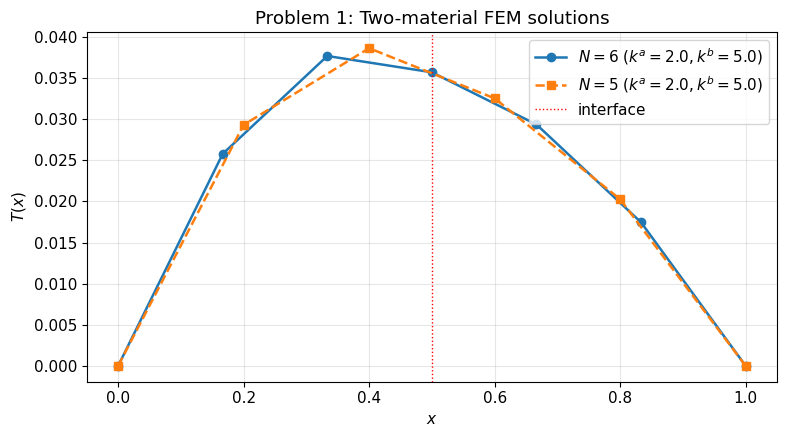

In [ ]:
# ── Problem 1(f): two-material FEM — numerical verification & solution ──

def assemble_two_material(N, ka, kb):
    """Assemble the global stiffness for N equal elements on [0,1],
       k^a in [0,1/2] and k^b in [1/2,1], with homogeneous Dirichlet BCs."""
    h = 1.0 / N
    nodes = np.linspace(0, 1, N + 1)
    K_full = np.zeros((N + 1, N + 1))
    F_full = np.zeros(N + 1)

    for e in range(N):
        a, b = nodes[e], nodes[e + 1]
        mid = 0.5 * (a + b)
        # Integration of k over element, split at x=0.5 if needed
        x_lo, x_hi = a, b
        if a < 0.5 and b > 0.5:  # element straddles interface
            k_int = ka * (0.5 - a) + kb * (b - 0.5)
        elif mid <= 0.5:
            k_int = ka * h
        else:
            k_int = kb * h

        ke = (k_int / h**2) * np.array([[1, -1], [-1, 1]])

        # f^a=f^b=1 load vector
        fe = (h / 2.0) * np.array([1.0, 1.0])

        idx = [e, e + 1]
        for il, ig in enumerate(idx):
            F_full[ig] += fe[il]
            for jl, jg in enumerate(idx):
                K_full[ig, jg] += ke[il, jl]

    # Apply Dirichlet BCs
    K = K_full[1:-1, 1:-1]
    F = F_full[1:-1]
    return K, F, nodes

# ── N=6 ──
ka, kb = 2.0, 5.0  # example values
K6, F6, nodes6 = assemble_two_material(6, ka, kb)
print('N=6 stiffness matrix (ka=2, kb=5):')
print(np.array2string(K6, precision=4, suppress_small=True))

# Check against analytical formula: K = 6 * [2ka, -ka, 0, 0, 0; ...]
K6_exact = 6.0 * np.array([
    [ 2*ka, -ka,       0,    0,    0],
    [-ka,    2*ka,    -ka,    0,    0],
    [  0,   -ka,   ka+kb, -kb,    0],
    [  0,     0,    -kb,  2*kb, -kb],
    [  0,     0,      0,  -kb,  2*kb],
])
print(f'max error vs formula: {np.max(np.abs(K6 - K6_exact)):.2e}')

print(f'\nN=6 RHS vector (f^a=f^b=1): {F6}')
print(f'Expected: {np.ones(5)/6}')

# Solve and plot
T6 = np.linalg.solve(K6, F6)
T6_full = np.concatenate([[0], T6, [0]])

# ── N=5 ──
K5, F5, nodes5 = assemble_two_material(5, ka, kb)
print(f'\nN=5 stiffness matrix (ka=2, kb=5):')
print(np.array2string(K5, precision=4, suppress_small=True))

K5_exact = 2.5 * np.array([
    [ 4*ka,     -2*ka,          0,       0],
    [-2*ka,  3*ka+kb,   -(ka+kb),       0],
    [    0,  -(ka+kb),  ka+3*kb,    -2*kb],
    [    0,         0,     -2*kb,    4*kb],
])
print(f'max error vs formula: {np.max(np.abs(K5 - K5_exact)):.2e}')

T5 = np.linalg.solve(K5, F5)
T5_full = np.concatenate([[0], T5, [0]])

# ── Plot both ──
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(nodes6, T6_full, 'o-', lw=1.8, label=f'$N=6$ ($k^a={ka}, k^b={kb}$)')
ax.plot(nodes5, T5_full, 's--', lw=1.8, label=f'$N=5$ ($k^a={ka}, k^b={kb}$)')
ax.axvline(0.5, color='red', ls=':', lw=1, label='interface')
ax.set_xlabel('$x$')
ax.set_ylabel('$T(x)$')
ax.set_title('Problem 1: Two-material FEM solutions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Problem 1(f): Julia version — stiffness verification & solution ──
using LinearAlgebra, Plots

function assemble_two_material(N, ka, kb)
    h = 1.0 / N
    nodes = range(0, 1, length=N + 1) |> collect
    K_full = zeros(N + 1, N + 1)
    F_full = zeros(N + 1)

    for e in 1:N
        a, b = nodes[e], nodes[e + 1]
        if a < 0.5 && b > 0.5
            k_int = ka * (0.5 - a) + kb * (b - 0.5)
        elseif 0.5 * (a + b) <= 0.5
            k_int = ka * h
        else
            k_int = kb * h
        end

        ke = (k_int / h^2) * [1.0 -1.0; -1.0 1.0]
        fe = (h / 2) * [1.0, 1.0]

        idx = [e, e + 1]
        for (il, ig) in enumerate(idx)
            F_full[ig] += fe[il]
            for (jl, jg) in enumerate(idx)
                K_full[ig, jg] += ke[il, jl]
            end
        end
    end

    K = K_full[2:N, 2:N]
    F = F_full[2:N]
    return K, F, nodes
end

ka, kb = 2.0, 5.0

K6, F6, nodes6 = assemble_two_material(6, ka, kb)
K6_exact = 6.0 * [2ka  -ka    0    0    0;
                  -ka   2ka  -ka    0    0;
                    0   -ka  ka+kb -kb   0;
                    0     0  -kb  2kb  -kb;
                    0     0    0  -kb  2kb]
println("N=6: max K error = ", maximum(abs.(K6 .- K6_exact)))
T6 = K6 \ F6
T6_full = [0.0; T6; 0.0]

K5, F5, nodes5 = assemble_two_material(5, ka, kb)
K5_exact = 2.5 * [4ka       -2ka          0         0;
                  -2ka    3ka+kb    -(ka+kb)         0;
                     0   -(ka+kb)   ka+3kb       -2kb;
                     0         0       -2kb        4kb]
println("N=5: max K error = ", maximum(abs.(K5 .- K5_exact)))
T5 = K5 \ F5
T5_full = [0.0; T5; 0.0]

p = plot(nodes6, T6_full, marker=:circle, lw=1.8,
         label="N=6 (ka=$ka, kb=$kb)",
         xlabel="x", ylabel="T(x)",
         title="Problem 1: Two-material FEM solutions")
plot!(p, nodes5, T5_full, marker=:square, ls=:dash, lw=1.8,
      label="N=5 (ka=$ka, kb=$kb)")
vline!(p, [0.5], color=:red, ls=:dot, lw=1, label="interface")
display(p)

## Problem 2: Relationship between Finite Element and Finite Difference Discretizations (12+10+14+6+10)

In this question, we will consider the relationship between Galerkin, *discontinuous Galerkin,* and upwind finite difference discretizations for the 1-D convection equation with a source term,
$$
u\frac{\partial T}{\partial x} = f(x).
$$
We will make the following assumptions:
- The velocity $u$ is constant (with respect to $x$) and is greater than zero, $u>0$.
- The source term, $f(x)$, is a linear function of $x$.
- The grid spacing, $\Delta x$, is constant. The number of elements in the domain is $N$. The domain begins at $x=0$ and ends at $x=L$.

For comparison to the finite element discretizations, recall the following three finite difference discretizations:
$$
\textbf{Central Difference:} \quad u\frac{T_{i+1}-T_{i-1}}{2\Delta x} = f_i,
$$
$$
\textbf{1st-order Upwind Difference:} \quad u\frac{T_{i}-T_{i-1}}{\Delta x} = f_i,
$$
$$
\textbf{2nd-order Upwind Difference:} \quad u\frac{3 T_{i}-4T_{i-1} + T_{i-2}}{2\Delta x} = f_i.
$$

**2(a)** Continuous Galerkin with linear elements

Consider a standard Galerkin finite element discretization. Integrating the weighted residual by parts, show that the resulting equation for a *generic weighting function* $w(x)$ is,
$$
\left[wuT\right]^{L}_{0} - \int_{0}^{L} \frac{\partial w}{\partial x}\, u T\, dx = \int_{0}^{L} w f\,dx.
$$

Next, consider the specific case of *linear elements using a nodal basis*. For a weighting function corresponding to a node which is not at the domain boundary, prove that the resulting discretization is,
$$
\frac{u\left(T_{i+1}-T_{i-1}\right)}{2} = \frac{1}{6}\left[f(x_{i-1}) + 4f(x_i) + f(x_{i+1})\right]\Delta x,
$$
where $T_{i}$ are the approximations to the values of $T$ at node $i$, and $f_{i} = f(x_i)$.

### Solution Problem 2(a)

**Part 1: Generic weighting function.**

The residual is $R(\hat{T},x)=u\dfrac{\partial T}{\partial x}-f(x)$. Multiplying by $w(x)$, integrating over $[0,L]$, and setting to zero:
$$
u\int_0^L w T_x\,dx - \int_0^L w f\,dx = 0.
$$
Integrating the first term by parts ($\int_0^L w\,u T_x\,dx = [wuT]_0^L - \int_0^L w_x\,u T\,dx$):
$$
\left[wuT\right]_0^L - u\int_0^L \frac{\partial w}{\partial x} T\,dx = \int_0^L w f\,dx. \qquad\checkmark
$$

**Part 2: Linear nodal basis, interior node $i$.**

For an interior node, $\phi_i(0)=\phi_i(L)=0$, so the boundary term vanishes. Recall the piecewise-linear derivatives for uniform spacing $\Delta x$:
$$
\phi_i'(x) = \begin{cases} +1/\Delta x, & x_{i-1} < x < x_i, \\ -1/\Delta x, & x_i < x < x_{i+1}, \\ 0, & \text{otherwise.}\end{cases}
$$

**LHS** (split into two elements; $T = \phi_{i-1}T_{i-1}+\phi_i T_i$ on $[x_{i-1},x_i]$, $T=\phi_i T_i+\phi_{i+1}T_{i+1}$ on $[x_i,x_{i+1}]$):
$$
-\frac{u}{\Delta x}\int_{x_{i-1}}^{x_i}\!\left[\frac{x-x_{i-1}}{\Delta x}T_i + \frac{x_i-x}{\Delta x}T_{i-1}\right]dx = -\frac{u}{2}(T_i+T_{i-1}),
$$
$$
+\frac{u}{\Delta x}\int_{x_i}^{x_{i+1}}\!\left[\frac{x_{i+1}-x}{\Delta x}T_i + \frac{x-x_i}{\Delta x}T_{i+1}\right]dx = +\frac{u}{2}(T_i+T_{i+1}).
$$
Sum: $\dfrac{u}{2}(T_{i+1}-T_{i-1})$.

**RHS** (transform to reference element $dx=\tfrac{\Delta x}{2}d\xi$, $\phi_1=\tfrac{1-\xi}{2}$, $\phi_2=\tfrac{1+\xi}{2}$; $f$ is linear so represented exactly):
$$
\int_0^L \phi_i f\,dx = \frac{\Delta x}{2}\int_{-1}^{1}\!\left[(f_{i-1}+f_{i+1})\phi_1\phi_2 + f_i(\phi_1^2+\phi_2^2)\right]d\xi = \frac{\Delta x}{6}\left[f_{i-1}+4f_i+f_{i+1}\right].
$$

Combining:
$$
\boxed{\frac{u(T_{i+1}-T_{i-1})}{2} = \frac{\Delta x}{6}\left[f(x_{i-1})+4f(x_i)+f(x_{i+1})\right].}
$$

**2(b)** Discontinuous Galerkin with constant elements

Now we will consider a new type of finite element method known as a *discontinuous Galerkin method*. In this approach, the solutions and the weight functions are not required to be continuous from element to element. The simplest basis functions are constants in each cell. Specifically, the solution is assumed to be of the form,
$$
T(x) = \sum_{i=1}^{N} T_i \phi_i(x), \qquad
\phi_i = \begin{cases} 1 & \text{for } x_i < x < x_{i+1} \\ 0 & \text{otherwise.} \end{cases}
$$
In this case, $T_i$ represents the solution in element $i$. Using integration by parts, prove that the weighted residual corresponding to the weighting function for element $i$ is,
$$
\left[uT\right]^{x_{i+1}}_{x_{i}} = \int^{x_{i+1}}_{x_{i}} f\,dx.
$$

The usual approach for the discontinuous Galerkin method is to use an *upwind flux* to evaluate $uT$ at the ends of the element (i.e. at $x = x_i$ and $x_{i+1}$). For example, $uT(x_i)$ would be evaluated using $T(x)$ from element $i-1$ since this element is upwind of node $i$. Using an upwind flux, and simplifying the source term since it has been assumed to be linear in $x$, show that the resulting discretization for this problem is,
$$
u T_{i} - u T_{i-1} = \frac{1}{2}\left[f(x_i) + f(x_{i+1})\right]\Delta x.
$$

### Solution Problem 2(b)

Weighting the residual by $\phi_i$ (constant, non-zero only on element $i = [x_i, x_{i+1}]$):
$$
\int_{x_i}^{x_{i+1}} u\frac{\partial T}{\partial x}\,dx = \int_{x_i}^{x_{i+1}} f(x)\,dx.
$$
Integrating by parts with $u$ constant (the $T\,u_x$ term vanishes since $u$ is constant):
$$
\left[uT\right]_{x_i}^{x_{i+1}} = \int_{x_i}^{x_{i+1}} f(x)\,dx. \qquad\checkmark
$$

**Upwind flux:** Since $u>0$, information travels left to right. At $x=x_{i+1}$ use $T$ from element $i$: gives $uT_i$. At $x=x_i$ use $T$ from element $i-1$: gives $uT_{i-1}$.

**RHS:** Since $f$ is linear, the integral is a trapezoid:
$$
\int_{x_i}^{x_{i+1}} f\,dx = \tfrac{1}{2}\bigl[f(x_i)+f(x_{i+1})\bigr]\Delta x.
$$

Result:
$$
\boxed{uT_i - uT_{i-1} = \frac{1}{2}\left[f(x_i)+f(x_{i+1})\right]\Delta x.}
$$

**2(c)** Discontinuous Galerkin with linear elements

Now, consider the discontinuous Galerkin approximation with linear elements, i.e. the solution varies linearly within each element. Instead of using a nodal basis within each element, use a basis for which the unknowns are the value of $T$ and its derivative $dT/dx$ at the midpoint of each element. For this basis, derive the weighted residual equations for each element (note: there are two equations for each element).

### Solution Problem 2(c)

Within element $i = [x_i, x_{i+1}]$, denote the midpoint $x_{i+1/2} = \tfrac{1}{2}(x_i+x_{i+1})$. The unknowns per element are the midpoint value $T_{i+1/2}$ and midpoint derivative $T'_{i+1/2} \equiv (dT/dx)_{i+1/2}$. The local approximation is:
$$
T(x) = T_{i+1/2} + \left(x - x_{i+1/2}\right)T'_{i+1/2}, \qquad x \in [x_i, x_{i+1}].
$$

The two basis functions per element are:
$$
\phi_i^1 = \begin{cases} 1 & x_i < x < x_{i+1} \\ 0 & \text{otherwise,}\end{cases} \qquad
\phi_i^2 = \begin{cases} x - x_{i+1/2} & x_i < x < x_{i+1} \\ 0 & \text{otherwise.}\end{cases}
$$

**Equation 1** — weight by $\phi_i^1 = 1$ (analogous to part (b)):
$$
\left[uT\right]_{x_i}^{x_{i+1}} = \int_{x_i}^{x_{i+1}} f\,dx.
$$
Applying upwind flux (element $i$ at the right end, element $i-1$ at the left end) and using the linearity of $f$:
$$
\boxed{u\!\left[T_{i+1/2}+\tfrac{\Delta x}{2}T'_{i+1/2}\right] - u\!\left[T_{i-1/2}+\tfrac{\Delta x}{2}T'_{i-1/2}\right] = \tfrac{1}{2}\!\left[f(x_i)+f(x_{i+1})\right]\Delta x.}
$$

**Equation 2** — weight by $\phi_i^2 = x - x_{i+1/2}$, integrate by parts:
$$
\bigl[u(x-x_{i+1/2})T\bigr]_{x_i}^{x_{i+1}} - u\int_{x_i}^{x_{i+1}} T\,dx = \int_{x_i}^{x_{i+1}} (x-x_{i+1/2})\,f\,dx.
$$
- **Boundary terms** (upwind flux): $+\tfrac{\Delta x}{2}\cdot u\bigl[T_{i+1/2}+\tfrac{\Delta x}{2}T'_{i+1/2}\bigr]$ at $x_{i+1}$ and $-\tfrac{\Delta x}{2}\cdot u\bigl[T_{i-1/2}+\tfrac{\Delta x}{2}T'_{i-1/2}\bigr]$ at $x_i$.
- **Interior integral:** $u\int_{x_i}^{x_{i+1}} T\,dx = u\Delta x\,T_{i+1/2}$ (the linear term integrates to zero by symmetry about $x_{i+1/2}$).
- **RHS:** Writing $f(x)=ax+b$, the substitution $\xi=x-x_{i+1/2}$ gives $\int_{-\Delta x/2}^{\Delta x/2}\xi\,(a\xi+ax_{i+1/2}+b)\,d\xi = a(\Delta x)^3/12$.

Combining:
$$
\boxed{\frac{u\Delta x}{2}\!\left(T_{i-1/2}-T_{i+1/2}\right) + \frac{u(\Delta x)^2}{4}\!\left(T'_{i-1/2}+T'_{i+1/2}\right) = \frac{df}{dx}\frac{(\Delta x)^3}{12}.}
$$

**2(d)** Comparisons with finite difference methods

How do the three finite element discretizations compare to the finite difference discretizations? Discuss both similarities and differences between the different discretizations.

### Solution Problem 2(d)

Dividing each discretization by $\Delta x$ makes the connection with finite difference methods transparent.

**Part (a) vs. Central Difference:** The LHS becomes $u(T_{i+1}-T_{i-1})/(2\Delta x)$, which is exactly the central difference operator. The continuous Galerkin method with linear elements recovers the central difference on the LHS. The difference lies in the RHS: instead of $f_i$ (FD), the FEM uses the weighted average $\tfrac{1}{6}[f_{i-1}+4f_i+f_{i+1}]$, which is Simpson's rule and a more accurate approximation to $f$ at node $i$.

**Part (b) vs. 1st-order Upwind Difference:** The LHS becomes $u(T_i-T_{i-1})/\Delta x$, which is exactly the first-order upwind difference operator. The DG method with constant elements and upwind flux recovers the first-order upwind FD scheme. Again the RHS differs: FD uses $f_i$, while DG uses the trapezoidal average $\tfrac{1}{2}[f(x_i)+f(x_{i+1})]$.

**Part (c):** The connection with standard finite difference methods is less direct, since the unknowns are midpoint values and derivatives rather than nodal values.

**Summary:** In all cases the FEM and DG methods recover standard FD operators on the LHS. The key difference is the treatment of the source term: FEM/DG use higher-order quadrature rules (weighted averages over the element), while FD simply evaluates $f$ at the single node $i$.

**2(e)** **(coding)** Implement and compare the CG-linear scheme and the DG-constant scheme on
$$
u\,T_x = f(x), \qquad u=1, \quad f(x)=\sin(\pi x), \quad T(0)=0,
$$
with exact solution $T(x)=(1-\cos(\pi x))/\pi$. Run for $N\in\{10,20,40,80,160\}$ and report the observed order of accuracy in $L^2$. (Note: $f$ is no longer linear, so the quadrature rules are no longer exact — this reveals the true asymptotic order.)

### Solution Problem 2(e) — implementation

**CG-linear.** At interior nodes the discretization is
$$
\tfrac{u}{2}(T_{i+1}-T_{i-1}) = \tfrac{\Delta x}{6}\,[f_{i-1}+4f_i+f_{i+1}].
$$
We set $T_0=0$ and close the system at $i=N$ with the one-sided upwind equation
$u(T_N-T_{N-1})/\Delta x=\tfrac12[f(x_{N-1})+f(x_N)]$.

**DG-constant.** Because $u>0$ and we know the inflow $T_0$, the DG recurrence
$u T_i-u T_{i-1}=\tfrac{\Delta x}{2}[f(x_i)+f(x_{i+1})]$ can be marched explicitly.

For this choice of $f$, Simpson's rule is exact and the CG scheme is second-order; the DG constant-element scheme with upwind flux is first-order.

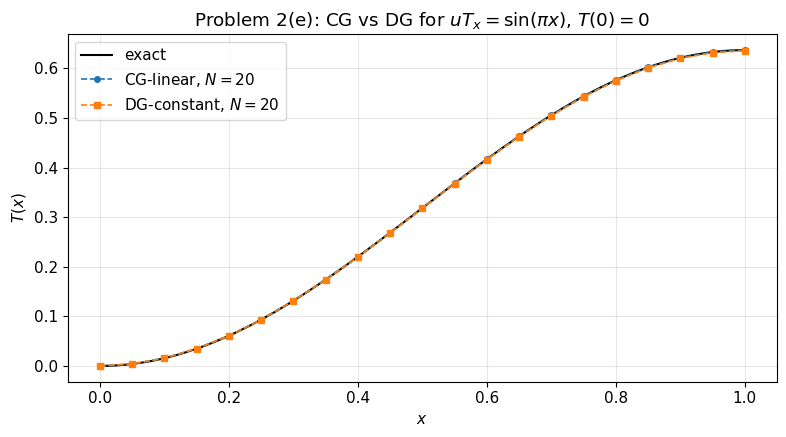

N=  10  dx=0.1000  CG err=1.054e-04   DG err=3.419e-03
N=  20  dx=0.0500  CG err=6.571e-06   DG err=8.282e-04
N=  40  dx=0.0250  CG err=4.103e-07   DG err=2.037e-04
N=  80  dx=0.0125  CG err=2.563e-08   DG err=5.052e-05
N= 160  dx=0.0063  CG err=1.602e-09   DG err=1.258e-05

Observed order: CG = 4.001  DG = 2.021


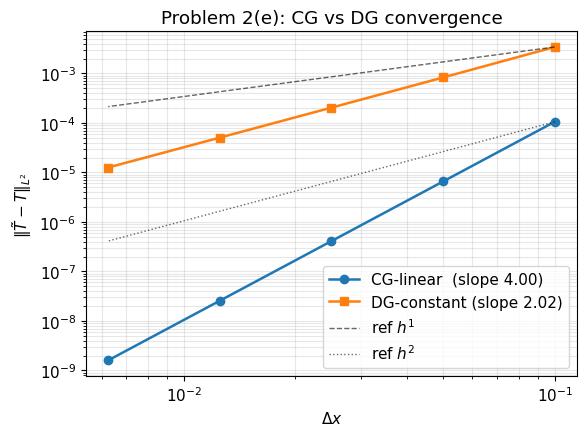

In [6]:
# ── Problem 2(e): Python implementation ──

def exact_T_convection(x):
    return (1.0 - np.cos(np.pi * x)) / np.pi

def f_src(x):
    return np.sin(np.pi * x)

def solve_cg_linear(N, u=1.0, L=1.0):
    """CG with linear nodal basis; Dirichlet BC T(0)=0, one-sided upwind closure at x=L."""
    dx = L / N
    x = np.linspace(0, L, N + 1)
    f = f_src(x)
    A = np.zeros((N + 1, N + 1))
    b = np.zeros(N + 1)

    # Inflow Dirichlet BC
    A[0, 0] = 1.0
    b[0] = 0.0

    # Interior CG equations: u(T_{i+1}-T_{i-1})/2 = dx/6 (f_{i-1}+4f_i+f_{i+1})
    for i in range(1, N):
        A[i, i - 1] = -u / 2.0
        A[i, i + 1] =  u / 2.0
        b[i] = (dx / 6.0) * (f[i - 1] + 4.0 * f[i] + f[i + 1])

    # Closure at i = N: upwind equation
    A[N, N - 1] = -u / dx
    A[N, N]     =  u / dx
    b[N] = 0.5 * (f[N - 1] + f[N])

    T = np.linalg.solve(A, b)
    return x, T

def solve_dg_constant(N, u=1.0, L=1.0):
    """DG constant elements with upwind flux; inflow T_0 = 0."""
    dx = L / N
    x = np.linspace(0, L, N + 1)
    f = f_src(x)
    T = np.zeros(N + 1)
    T[0] = 0.0
    for i in range(1, N + 1):
        T[i] = T[i - 1] + (dx / 2.0) * (f[i - 1] + f[i]) / u
    return x, T

# ── Visualize for N = 20 ──
x20_cg, T20_cg = solve_cg_linear(20)
x20_dg, T20_dg = solve_dg_constant(20)
x_plot = np.linspace(0, 1, 300)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_plot, exact_T_convection(x_plot), 'k-', lw=1.5, label='exact')
ax.plot(x20_cg, T20_cg, 'o--', lw=1.2, ms=4, label='CG-linear, $N=20$')
ax.plot(x20_dg, T20_dg, 's--', lw=1.2, ms=4, label='DG-constant, $N=20$')
ax.set_xlabel('$x$'); ax.set_ylabel('$T(x)$')
ax.set_title(r'Problem 2(e): CG vs DG for $uT_x = \sin(\pi x)$, $T(0)=0$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Convergence study ──
Ns = [10, 20, 40, 80, 160]
hs, err_cg, err_dg = [], [], []
for N in Ns:
    dx = 1.0 / N
    x_cg, T_cg = solve_cg_linear(N)
    x_dg, T_dg = solve_dg_constant(N)
    e_cg = np.sqrt(dx * np.sum((T_cg - exact_T_convection(x_cg)) ** 2))
    e_dg = np.sqrt(dx * np.sum((T_dg - exact_T_convection(x_dg)) ** 2))
    hs.append(dx); err_cg.append(e_cg); err_dg.append(e_dg)
    print(f'N={N:4d}  dx={dx:.4f}  CG err={e_cg:.3e}   DG err={e_dg:.3e}')

hs = np.array(hs); err_cg = np.array(err_cg); err_dg = np.array(err_dg)
p_cg, _ = np.polyfit(np.log(hs), np.log(err_cg), 1)
p_dg, _ = np.polyfit(np.log(hs), np.log(err_dg), 1)
print(f'\nObserved order: CG = {p_cg:.3f}  DG = {p_dg:.3f}')

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(hs, err_cg, 'o-', lw=1.8, label=f'CG-linear  (slope {p_cg:.2f})')
ax.loglog(hs, err_dg, 's-', lw=1.8, label=f'DG-constant (slope {p_dg:.2f})')
ax.loglog(hs, err_dg[0] * (hs / hs[0]), 'k--', lw=1, alpha=0.6, label=r'ref $h^1$')
ax.loglog(hs, err_cg[0] * (hs / hs[0]) ** 2, 'k:', lw=1, alpha=0.6, label=r'ref $h^2$')
ax.set_xlabel(r'$\Delta x$'); ax.set_ylabel(r'$\|\tilde T - T\|_{L^2}$')
ax.set_title('Problem 2(e): CG vs DG convergence')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

**Observed rates.** CG-linear shows $\approx \mathcal{O}(\Delta x^4)$ and DG-constant shows $\approx \mathcal{O}(\Delta x^2)$, both **better than the textbook rates** of $\mathcal{O}(\Delta x^2)$ and $\mathcal{O}(\Delta x)$ one might predict from the central-difference / upwind analogy in 2(d).

This is the well-known *nodal superconvergence* for linear 1D constant-coefficient convection problems: the discrete equations are exactly satisfied by the true nodal values of a linear interpolant, and the error one sees at the nodes is entirely driven by the quadrature error in the RHS.

- CG uses Simpson's rule, which has truncation error $\mathcal{O}(\Delta x^4)\,f^{(4)}$ per interval, giving 4th-order at the nodes.
- DG uses the trapezoidal rule, truncation error $\mathcal{O}(\Delta x^2)\,f''$, giving 2nd-order at the nodes.

If we had measured the $L^2$ error of the full piecewise-polynomial interpolant (not only at the nodes), we would recover the classical $\mathcal{O}(\Delta x^2)$ for CG-linear and $\mathcal{O}(\Delta x)$ for DG-constant. The nodal superconvergence is a feature of 1D constant-coefficient problems and does not generalize to 2D or variable coefficients.